# Housing Unit Allocation with Person Record File Full Workflow

## Overview
This code works with the National Structures Inventory to run the housing unit allocation (HUA) and the person record file (PREC) workflow.
The HUA process is generalizable to any county in the United States. The HUA process will work for any file that has locations of structures and some basic information about the buildings.
The process is designed to work with [IN-CORE](https://incore.ncsa.illinois.edu/), a community resilience modeling environment.
Using IN-CORE requires an account and access to the IN-CORE Dataservice.

Functions are provided to obtain and clean data required for the version 2 Housing Unit Allocation. 

## Required Inputs
Program requires the following inputs:
If using the National Structures Inventory there are no required inputs.

[Census API KEY *REQUIRED*](CENSUS_API_KEY.md) See CENSUS_API_KEY.md file for more details.
    
## Output Description
The output of this workflow is a CSV file with the housing unit inventory allocated to a building inventory using the housing unit allocation model.

The output CSV is designed to be used in the Interdependent Networked Community Resilience Modeling Environment (IN-CORE).

IN-CORE is an open source python package that can be used to model the resilience of a community. To download IN-CORE, see:

https://incore.ncsa.illinois.edu/


## Instructions
Users can run the workflow by executing each block of code in the notebook.

## Description of Program
- program:    ncoda_07jv3_HUA_NSI_Hayward
- task:       Start with NSI building inventory, run housing unit allocation algorithm, and then run person record file algorithm
- See github commits for description of program updates
- Current Version: v3 - 
- 2024-02-20 - Combine code from 07c, 07d, and 07e into one notebook
- 2024-05-22 - removed the drop down menu, did not work consistently
- 2025-02-21 - Test with 2020 HUI
- 2025-03-07 - Update to version 2 to differentiate running 2010 and 2020
- 2025-03-27 - V3 Solved issue for states starting with 0 FIPS code - major modification to code
- 2025-09-17 - Adjust code to run a Monte Carlo Simulation
- 2026-04-16 - Running code to explore missing building data
- 2026-05-23 - v2.1.0 PR 136 change to address point prediction
             - Census API Key NOW REQUIRED
- project:    Interdependent Networked Community Resilience Modeling Environment (IN-CORE), Subtask 5.2 - Social Institutions
- funding:	  NIST Financial Assistance Award Numbers: 70NANB15H044 and 70NANB20H008
- funding:	  Southeast Texas Urban Integrated Field Lab Department of Energy DE-SC0023216 
- author:     Nathanael Rosenheim

## Required Citations:
Rosenheim, Nathanael, Roberto Guidotti, Paolo Gardoni & Walter Gillis Peacock. (2021). Integration of detailed household and housing unit characteristic data with critical infrastructure for post-hazard resilience modeling. _Sustainable and Resilient Infrastructure_. 6(6), 385-401. https://doi.org/10.1080/23789689.2019.1681821

Rosenheim, Nathanael (2021) “Detailed Household and Housing Unit Characteristics: Data and Replication Code.” _DesignSafe-CI_. 
https://doi.org/10.17603/ds2-jwf6-s535.

In [54]:
# To reload submodules need to use this magic command to set autoreload on
%load_ext autoreload
%autoreload 2
from pyncoda.ncoda_00g_community_options import *
from IPython.display import display

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### How to set up the Community Dictionary
Please review the python code in the file pyncoda/ncoda_00g_community_options.py

In this file you will find a collection of data dictionaries with various ways to setup the inputs for the Housing Unit Allocation process. 

The basic dictionary includes the name of the community, the county FIPS code, your input building inventory file, and key variables in the building inventory file.

In [55]:
# select a community from this list
# if your community is not in this list, add it to the file ncoda_00g_community_options.py
list_community_options(communities_dictionary)

['Lumberton, NC: IN-CORE Building inventory for Robeson County, NC',
 'Galveston, TX: IN-CORE Building inventory for Galveston County, TX',
 'Galveston, TX: NSI Building inventory for Galveston County, TX',
 'Galveston, TX: IN-CORE Building inventory for Galveston Island, TX',
 'Mayfield, KY: NSI Building inventory for Graves County, KY',
 'Beaumont, TX: NSI Building inventory for Jefferson County, TX',
 'Beaumont, TX: Safayet Building inventory for Jefferson County, TX',
 'Pentwater, MI: NSI Building inventory for Oceana County, MI',
 'Seaside, OR: NSI Building inventory for Clatsop County, OR',
 'Lane County, OR: NSI Building inventory for Lane County, OR',
 'Benton County, OR: NSI Building inventory for Benton County, OR',
 'Southeast Texas Urban Integrated Field Lab: NSI Building inventory for Southeast Texas',
 'Southeast Texas Urban Integrated Field Lab (12 neighbor counties): NSI Building inventory for Southeast Texas',
 'Brazos County, TX: NSI Building inventory for Brazos Coun

In [56]:
community_id_by_name = 'Hayward, CA: NSI Building inventory for Alameda County, CA, 2010'

In [57]:
community_id, focalplace, countyname, countyfips = get_community_id_by_name(community_id_by_name)
communities = {community_id : communities_dictionary[community_id]}

Selected community ID: Hayward_CA_NSI
Hayward, CA is in CALIFORNIA
Focal place: Hayward
Hayward, CA is in Alameda County, CA with FIPS code 06001
Use IN-CORE: False


## Setup Python Environment

In [58]:
import pandas as pd
import geopandas as gpd # For reading in shapefiles
import numpy as np
import sys # For displaying package versions
import os # For managing directories and file paths if drive is mounted
import scooby # Reports Python environment

import contextily as cx # For adding basemap tiles to plot
import matplotlib.pyplot as plt # For plotting and making graphs

In [59]:
# open, read, and execute python program with reusable commands
from pyncoda.ncoda_00d_cleanvarsutils import *
from pyncoda.ncoda_04c_poptableresults import *
from pyncoda.ncoda_07i_process_communities import process_community_workflow

In [60]:
# Generate report of Python environment
base_packages = ['pandas','ipyleaflet','seaborn','contextily']
incore_packages = ['pyincore','pyincore_viz']
check_packages = base_packages + incore_packages
print(scooby.Report(additional=check_packages))


--------------------------------------------------------------------------------
  Date: Sat May 23 12:48:21 2026 Eastern Daylight Time

                OS : Windows (10 10.0.26200 SP0 Multiprocessor Free)
            CPU(s) : 16
           Machine : AMD64
      Architecture : 64bit
               RAM : 31.7 GiB
       Environment : Jupyter

  Python 3.10.14 | packaged by Anaconda, Inc. | (main, May  6 2024, 19:44:50)
  [MSC v.1916 64 bit (AMD64)]

            pandas : 2.2.2
        ipyleaflet : Module not found
           seaborn : 0.13.2
        contextily : 1.6.0
          pyincore : Module not found
      pyincore_viz : Module not found
             numpy : 1.26.4
             scipy : 1.13.1
           IPython : 8.25.0
        matplotlib : 3.8.4
            scooby : 0.10.0

  Intel(R) oneAPI Math Kernel Library Version 2023.1-Product Build 20230303
  for Intel(R) 64 architecture applications
--------------------------------------------------------------------------------


In [61]:
# Check working directory - good practice for relative path access
os.getcwd()

'c:\\Users\\nathanael99\\MyProjects\\GitHub\\intersect-community-data'

## Run Housing Unit Allocation
The following code will produce the following outputs:
1. Housing Unit Inventory
2. Address Point Inventory
3. Housing Unit Allocation

In [62]:
basevintage_options = ['2010']

Running iteration 1 of 1 for basevintage 2010 with seed 9876
Creating folder OutputData/Hayward_CA_NSI to store output.
Creating folder OutputData/Hayward_CA_NSI/00_logfiles
     logfiles Folder purpose: Store text files with log of workflow.
Creating folder OutputData/Hayward_CA_NSI/01_CommunitySourceData
     CommunitySourceData Folder purpose: Source source data files. Helps with software development and replication.
Creating folder OutputData/Hayward_CA_NSI/02_TidyCommunitySourceData
     TidyCommunitySourceData Folder purpose: Cleaned source data and inputs for base inventory.
Creating folder OutputData/Hayward_CA_NSI/03_BaseInventory
     BaseInventory Folder purpose: Initial inventories before random merge. Use as inputs to uncertainty propagation.
Creating folder OutputData/Hayward_CA_NSI/04_RandomMerge
     RandomMerge Folder purpose: Results of random merge with flag columns.
Creating folder OutputData/Hayward_CA_NSI/05_Verify
     Verify Folder purpose: Results to compare in

c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:765: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  set_flag_df.loc[conditions, self.flaggeo_var] = .5


Sorting before random merge order by ['County2010', 'race', 'hispan', 'incomegroup', 'random_order']
Generating random merge order by ['County2010', 'race', 'hispan', 'incomegroup']
    Setting up  secondary data with primary key and flags
Geolevels available ['state', 'county', 'tract']
Geolvarids available ['Tract2010']
Adding County2010 expected length 5
Dataframe has Tract 2010 for new geovar County2010
Confirming County2010 has expected length.
Checking primary key name uniqueidB19101
Primary key variable uniqueidB19101 is unique.
Primary key uniqueidB19101 has no missing values
['uniqueidB19101', 'County2010', 'Tract2010', 'index', 'GEO_ID', 'state', 'county', 'tract', 'race', 'hispan', 'incomegroup', 'hu_counter', 'family', 'family_flagsetrm', 'family_Tract2010_flagsetrm']
Initializing geovar flag set variable for family at geolevel County2010
New flag: family_County2010_flagsetrm
Observations without primary flag set 0
Observations without geovar flag set 378492
After updated o

c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:765: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  set_flag_df.loc[conditions, self.flaggeo_var] = .5


Geolevels available ['state', 'county', 'tract']
Geolvarids available ['County2010', 'Tract2010']
Adding County2010 expected length 5
Dataframe has Tract 2010 for new geovar County2010
Confirming County2010 has expected length.
Checking primary key name uniqueidB19001
Primary key variable uniqueidB19001 is unique.
Primary key uniqueidB19001 has no missing values
['uniqueidB19001', 'County2010', 'Tract2010', 'index', 'GEO_ID', 'state', 'county', 'tract', 'race', 'hispan', 'hu_counter', 'family', 'incomegroup', 'family_flagsetrm', 'family_Tract2010_flagsetrm', 'family_County2010_flagsetrm', 'incomegroup_flagsetrm', 'incomegroup_Tract2010_flagsetrm']
Initializing geovar flag set variable for incomegroup at geolevel County2010
New flag: incomegroup_County2010_flagsetrm
Observations without primary flag set 37851
Observations without geovar flag set 577521
After updated observations without geovar flag set 37851
Setting 37851 flags for incomegroup secondary data not used.
0 observations do 

c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:788: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '7.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  set_flag_df.loc[conditions, self.flaggeo_var] = self.round+.5
c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\pyncoda\CommunitySourceData\api_census_gov\acg_02a_add_categorical_char.py:788: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '8.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  set_flag_df.loc[conditions, self.flaggeo_var] = self.round+.5


Flag vars available ['family_flagsetrm', 'family_Tract2010_flagsetrm', 'family_County2010_flagsetrm', 'incomegroup_flagsetrm', 'incomegroup_Tract2010_flagsetrm', 'incomegroup_County2010_flagsetrm']
Before update output_df observations flag set 8 = 0
Before update results observations flag set 8 = 4658
After update observations geovar flag set 8 = 4658
    Check random merge results for primary data.
Check by geovar flag incomegroup_County2010_flagsetrm
Observations flag not equal to 0 583472
Input and output data have the same length 583472
Outputdata has 583472 Observations with predicted incomegroup
Percent left to predict:  0.00
    Overwrite input data with update output data.
Flag vars available ['family_flagsetrm', 'family_Tract2010_flagsetrm', 'family_County2010_flagsetrm', 'incomegroup_flagsetrm', 'incomegroup_Tract2010_flagsetrm', 'incomegroup_County2010_flagsetrm']
Before update output_df observations flag set 8 = 0
Before update results observations flag set 8 = 4658
After u

c:\Users\nathanael99\MyProjects\GitHub\intersect-community-data\pyncoda\ncoda_07d_run_hua_workflow.py:173: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.5 1.5 1.5 ... 1.5 1.5 1.5]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  addptv2_df.loc[condition1 & condition2 & condition3,'ownershp1'] \


Round 1
Performing random merge at geography level: Block
Attempt to merge hui on all common group vars.
Running random merge by ['Block2010', 'huicounter3', 'ownershp1']
    Setting up  primary data with primary key and flags
Adding Block2010 to column list
Geolevels available []
Geolvarids available ['Block2010']
Adding Block2010 expected length 15
Dataframe has Block 2010 for new geovar Block2010
Confirming Block2010 has expected length.
Checking primary key name huid
Primary key variable huid is unique.
Primary key huid has no missing values
['huid', 'Block2010', 'blockid', 'bgid', 'tractid', 'FIPScounty', 'numprec', 'ownershp', 'race', 'hispan', 'family', 'vacancy', 'gqtype', 'incomegroup', 'hhinc', 'randincome', 'poverty', 'BLOCKID10_str', 'huicounter1', 'huicounter2', 'huicounter3', 'ownershp1', 'ownershp2', 'ownershp3', 'strctid', 'strctid_flagsetrm', 'strctid_Block2010_flagsetrm', 'addrptid', 'fd_id_bid', 'huestimate', 'huicounter_addpt', 'placeNAME10', 'x', 'y']
Observations 

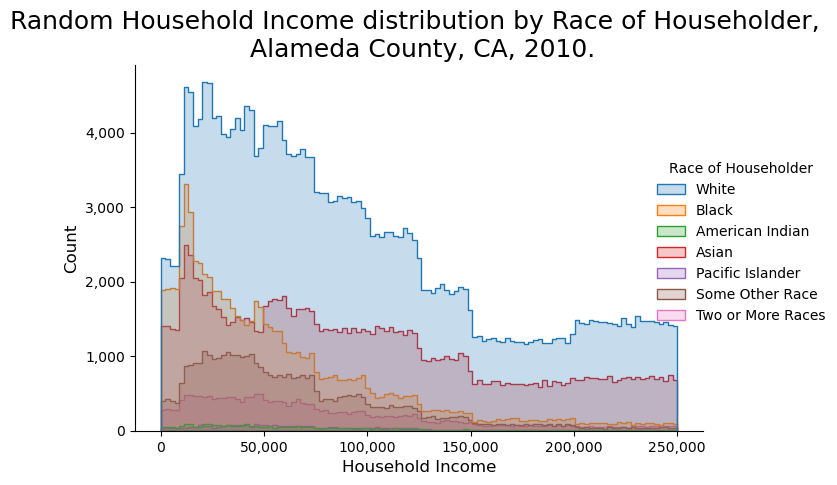

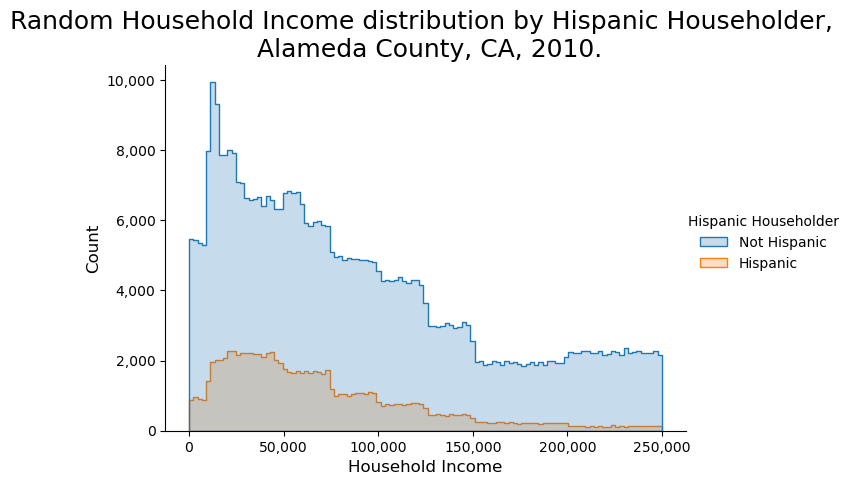

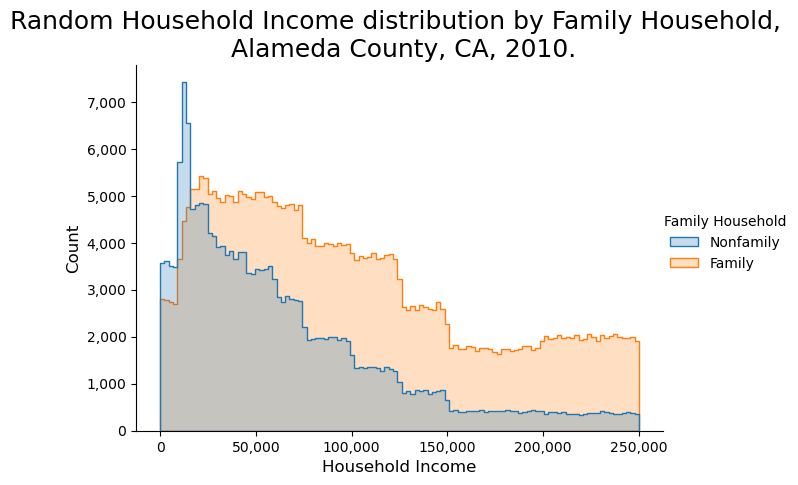

In [63]:
hua_hui_gdf_dict = {}
base_seed = 9876
iterations = 1
# iterate through basevintage options to run Monte Carlo Simulation
for basevintage in basevintage_options:
    hua_hui_gdf_dict[basevintage] = {}
    for i in range(iterations):
        seed_i = base_seed + i
        print(f"Running iteration {i+1} of {iterations} for basevintage {basevintage} with seed {seed_i}")
        workflow = process_community_workflow(
                    communities,
                    seed = seed_i,
                    version = '2.2.0',
                    version_text = 'v2-2-0',
                    basevintage = basevintage,
                    outputfolder ="OutputData",
                    outputfolders = {},
                    savefiles = True)
        hua_hui_gdf_dict[basevintage][seed_i] = workflow.process_communities()

## Explore and Validate Housing Unit Allocation


### Look at population characteristics and compare to US Census

In [64]:
focalplace = communities[community_id]['community_name']
print(focalplace, focalplace, countyname, countyfips)

Hayward, CA Hayward, CA Alameda County, CA 06001


In [65]:
hua_gdf = hua_hui_gdf_dict['2010'][9876]

In [66]:
PopResultsTable.pop_results_table(
                  input_df = hua_gdf, 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = '2010 (9876)',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied (%),2 Renter Occupied (%),Total Population by Households (%)
Race Ethnicity,,,
"1 White alone, Not Hispanic","354,848 (43.4%)","176,870 (27.8%)","531,718 (36.5%)"
"2 Black alone, Not Hispanic","59,667 (7.3%)","111,333 (17.5%)","171,000 (11.8%)"
"3 American Indian and Alaska Native alone, Not Hispanic","1,468 (0.2%)","2,057 (0.3%)","3,525 (0.2%)"
"4 Asian alone, Not Hispanic","240,249 (29.4%)","134,042 (21.0%)","374,291 (25.7%)"
"5 Other Race, Not Hispanic","23,368 (2.9%)","25,320 (4.0%)","48,688 (3.3%)"
"6 Any Race, Hispanic","138,722 (17.0%)","187,253 (29.4%)","325,975 (22.4%)"
Total,"818,322 (100.0%)","636,875 (100.0%)","1,455,197 (100.0%)"


In [67]:
PopResultsTable.pop_results_table(hua_gdf, 
                   who = "Median Household Income", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = '2010 (9876)',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied,2 Renter Occupied,Median Household Income
Race Ethnicity,,,
"1 White alone, Not Hispanic","$96,313","$69,092","$85,396"
"2 Black alone, Not Hispanic","$51,097","$39,144","$43,041"
"3 American Indian and Alaska Native alone, Not Hispanic","$66,294","$46,984","$53,527"
"4 Asian alone, Not Hispanic","$104,274","$66,249","$88,095"
"5 Other Race, Not Hispanic","$76,302","$57,312","$64,782"
"6 Any Race, Hispanic","$64,425","$51,340","$56,632"
Total,"$88,275","$56,883","$71,405"


In [68]:
hua_gdf.head()

,huid,blockid,bgid,tractid,FIPScounty,numprec,ownershp,race,hispan,family,...,hhinc,randincome,poverty,BLOCKID10_str,fd_id_bid,placeNAME10,huestimate,x,y,geometry
0,B060014001001007H0001,060014001001007,060014001001,06001400100,06001,1,1.0,1.0,0.0,0.0,...,5.0,122331.0,0.0,B060014001001007,nsi-474648750-849VVQ65+J2C-2-2-3-3,Oakland,2.0,-122.242497,37.861551,POINT (-122.24 37.862)
1,B060014001001007H0002,060014001001007,060014001001,06001400100,06001,1,1.0,1.0,0.0,0.0,...,5.0,249702.0,0.0,B060014001001007,nsi-474648764-849VVQ65+PW4-1-3-2-2,Oakland,2.0,-122.240157,37.861752,POINT (-122.24 37.862)
2,B060014001001007H0003,060014001001007,060014001001,06001400100,06001,1,1.0,1.0,0.0,0.0,...,4.0,81115.0,0.0,B060014001001007,nsi-474648761-849VVQ64+JV4-5-4-3-3,Oakland,2.0,-122.242793,37.861523,POINT (-122.24 37.862)
3,B060014001001007H0004,060014001001007,060014001001,06001400100,06001,1,1.0,1.0,0.0,0.0,...,5.0,185826.0,0.0,B060014001001007,nsi-474648762-849VVQ65+MC5-2-3-2-3,Oakland,2.0,-122.241380,37.861648,POINT (-122.24 37.862)
4,B060014001001007H0005,060014001001007,060014001001,06001400100,06001,1,1.0,1.0,0.0,0.0,...,5.0,173579.0,0.0,B060014001001007,nsi-474648765-849VVQ64+PQ7-2-2-2-3,Oakland,2.0,-122.243089,37.861795,POINT (-122.24 37.862)


In [69]:
# Show population counts by placeNAME10 - weight by numprec
hua_gdf.groupby('placeNAME10').size()

placeNAME10
Alameda            32372
Albany              7898
Ashland             7769
Berkeley           49583
Castro Valley      23428
Cherryland          4998
Dublin             15800
Emeryville          6649
Fairview            3702
Fremont            74046
Hayward            48347
Livermore          30396
Milpitas              32
Newark             13432
Oakland           169958
Piedmont            3925
Pleasanton         25956
San Leandro        32459
San Lorenzo         7685
Sunol                394
Unincorporated      3322
Union City         21321
dtype: int64

In [70]:
focalplace

'Hayward, CA'

In [71]:
# set dataframe for focal place
focalplace_hua_gdf =  hua_gdf.loc[hua_gdf['placeNAME10'] == 'Hayward'].copy(deep=True)

In [72]:
PopResultsTable.pop_results_table(focalplace_hua_gdf, 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = focalplace,
                  when = '2010 (9876)',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied (%),2 Renter Occupied (%),Total Population by Households (%)
Race Ethnicity,,,
"1 White alone, Not Hispanic","18,244 (24.9%)","9,813 (15.1%)","28,057 (20.3%)"
"2 Black alone, Not Hispanic","4,535 (6.2%)","10,175 (15.6%)","14,710 (10.6%)"
"3 American Indian and Alaska Native alone, Not Hispanic",173 (0.2%),224 (0.3%),397 (0.3%)
"4 Asian alone, Not Hispanic","20,695 (28.2%)","8,516 (13.1%)","29,211 (21.1%)"
"5 Other Race, Not Hispanic","3,917 (5.3%)","3,459 (5.3%)","7,376 (5.3%)"
"6 Any Race, Hispanic","25,702 (35.1%)","32,916 (50.6%)","58,618 (42.4%)"
Total,"73,266 (100.0%)","65,103 (100.0%)","138,369 (100.0%)"


In [73]:
PopResultsTable.pop_results_table(focalplace_hua_gdf, 
                   who = "Median Household Income", 
                  what = "by Race, Ethnicity",
                  where = focalplace,
                  when = '2010 (9876)',
                  row_index = "Race Ethnicity",
                  col_index = 'Tenure Status')

Tenure Status,1 Owner Occupied,2 Renter Occupied,Median Household Income
Race Ethnicity,,,
"1 White alone, Not Hispanic","$67,776","$53,986","$62,442"
"2 Black alone, Not Hispanic","$66,180","$51,543","$55,242"
"3 American Indian and Alaska Native alone, Not Hispanic","$71,456","$44,709","$62,751"
"4 Asian alone, Not Hispanic","$92,130","$70,579","$85,200"
"5 Other Race, Not Hispanic","$72,086","$58,260","$65,074"
"6 Any Race, Hispanic","$61,950","$52,269","$56,488"
Total,"$70,232","$55,004","$62,753"


In [74]:
hua_gdf['fd_id_bid'].describe()

count                                 583472
unique                                389001
top       nsi-475653265-849VRMQW+JPH-0-0-0-0
freq                                     673
Name: fd_id_bid, dtype: object

In [75]:
bldg_uniqueid = 'fd_id_bid'
# add category for missing building id
buildingdata_conditions = {'cat_var' : {'variable_label' : 'Building Data Availability',
                         'notes' : 'Does Housing Unit have building data?'},
              'condition_list' : {
                1 : {'condition': f"(df['{bldg_uniqueid}'] == 'missing building id')", 'value_label': "0 Missing Building Data"},
                2 : {'condition': f"(df['{bldg_uniqueid}'] != 'missing building id')", 'value_label': "1 Building Data Available"}}
            }
hua_gdf = add_label_cat_conditions_df(hua_gdf, conditions = buildingdata_conditions)

0 Missing Building Data had 370 observations
1 Building Data Available had 583102 observations


In [76]:
PopResultsTable.pop_results_table(hua_gdf, 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = countyname,
                  when = "2010",
                  row_index = "Race Ethnicity",
                  col_index = 'Building Data Availability_str',
                  row_percent = '0 Missing Building Data')

Building Data Availability_str,0 Missing Building Data (%),1 Building Data Available (%),Total Population by Households (%),Percent Row 0 Missing Building Data
Race Ethnicity,,,,
"1 White alone, Not Hispanic",247 (14.0%),"531,471 (35.6%)","531,718 (35.6%)",0.0%
"2 Black alone, Not Hispanic",125 (7.1%),"170,875 (11.5%)","171,000 (11.5%)",0.1%
"3 American Indian and Alaska Native alone, Not Hispanic",2 (0.1%),"3,523 (0.2%)","3,525 (0.2%)",0.1%
"4 Asian alone, Not Hispanic",235 (13.3%),"374,056 (25.1%)","374,291 (25.1%)",0.1%
"5 Other Race, Not Hispanic",48 (2.7%),"48,640 (3.3%)","48,688 (3.3%)",0.1%
"6 Any Race, Hispanic",205 (11.6%),"325,770 (21.9%)","325,975 (21.8%)",0.1%
7 Group Quarters no Race Ethnicity Data,903 (51.2%),"36,539 (2.5%)","37,442 (2.5%)",2.4%
Total,"1,765 (100.0%)","1,490,874 (100.0%)","1,492,639 (100.0%)",0.1%


In [77]:
focalplace_hua_gdf = add_label_cat_conditions_df(focalplace_hua_gdf, conditions = buildingdata_conditions)

PopResultsTable.pop_results_table(focalplace_hua_gdf, 
                  who = "Total Population by Households", 
                  what = "by Race, Ethnicity",
                  where = focalplace,
                  when = "2010",
                  row_index = "Race Ethnicity",
                  col_index = 'Building Data Availability_str',
                  row_percent = '0 Missing Building Data')

0 Missing Building Data had 8 observations
1 Building Data Available had 48339 observations


Building Data Availability_str,0 Missing Building Data (%),1 Building Data Available (%),Total Population by Households (%),Percent Row 0 Missing Building Data
Race Ethnicity,,,,
"1 White alone, Not Hispanic",nan (nan%),"28,057 (19.9%)","28,057 (19.9%)",nan%
"2 Black alone, Not Hispanic",nan (nan%),"14,710 (10.4%)","14,710 (10.4%)",nan%
"3 American Indian and Alaska Native alone, Not Hispanic",nan (nan%),397 (0.3%),397 (0.3%),nan%
"4 Asian alone, Not Hispanic",6 (15.8%),"29,205 (20.7%)","29,211 (20.7%)",0.0%
"5 Other Race, Not Hispanic",7 (18.4%),"7,369 (5.2%)","7,376 (5.2%)",0.1%
"6 Any Race, Hispanic",25 (65.8%),"58,593 (41.5%)","58,618 (41.5%)",0.0%
7 Group Quarters no Race Ethnicity Data,nan (nan%),"2,724 (1.9%)","2,724 (1.9%)",nan%
Total,38 (100.0%),"141,055 (100.0%)","141,093 (100.0%)",0.0%


In [78]:
PopResultsTable.pop_results_table(focalplace_hua_gdf, 
                  who = "Total Population by Households", 
                  what = "by Tenure Status",
                  where = focalplace,
                  when = "2010",
                  row_index = "Tenure Status",
                  col_index = 'Building Data Availability_str',
                  row_percent = '0 Missing Building Data')

Building Data Availability_str,0 Missing Building Data (%),1 Building Data Available (%),Total Population by Households (%),Percent Row 0 Missing Building Data
Tenure Status,,,,
1 Owner Occupied,30 (78.9%),"73,236 (52.9%)","73,266 (52.9%)",0.0%
2 Renter Occupied,8 (21.1%),"65,095 (47.1%)","65,103 (47.1%)",0.0%
Total,38 (100.0%),"138,331 (100.0%)","138,369 (100.0%)",0.0%


In [79]:
PopResultsTable.pop_results_table(focalplace_hua_gdf, 
                  who = "Total Population by Households", 
                  what = "by Income Groups",
                  where = focalplace,
                  when = "2010",
                  row_index = "Household Income Group",
                  col_index = 'Building Data Availability_str',
                  row_percent = '0 Missing Building Data')

Building Data Availability_str,0 Missing Building Data (%),1 Building Data Available (%),Total Population by Households (%),Percent Row 0 Missing Building Data
Household Income Group,,,,
"1 Less than $15,000",6 (15.8%),"11,143 (8.1%)","11,149 (8.1%)",0.1%
"2 $15,000 to $24,999",7 (18.4%),"11,089 (8.0%)","11,096 (8.0%)",0.1%
"3 $25,000 to $74,999",20 (52.6%),"58,628 (42.4%)","58,648 (42.4%)",0.0%
"4 $75,000 to $99,999",5 (13.2%),"18,081 (13.1%)","18,086 (13.1%)",0.0%
"5 $100,000 or more",nan (nan%),"39,390 (28.5%)","39,390 (28.5%)",nan%
Total,38 (100.0%),"138,331 (100.0%)","138,369 (100.0%)",0.0%


#### Validate the Housing Unit Allocation has worked
Notice that the population count totals for the community
should match (pretty closely) data collected for the 2010 Decennial Census.
This can be confirmed by going to data.census.gov

In [80]:
print("Total Population by Race and Ethnicity:")
print(f"https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=DECENNIALSF12010.P5")

print("Median Income by Race and Ethnicity:")
print(f"All Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2012.B19013")
print(f"Black Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2012.B19013B")
print(f"White, not Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2012.B19013H")
print(f"Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US{countyfips}&tid=ACSDT5Y2012.B19013I")

Total Population by Race and Ethnicity:
https://data.census.gov/cedsci/table?g=050XX00US06001&tid=DECENNIALSF12010.P5
Median Income by Race and Ethnicity:
All Households: https://data.census.gov/cedsci/table?g=050XX00US06001&tid=ACSDT5Y2012.B19013
Black Households: https://data.census.gov/cedsci/table?g=050XX00US06001&tid=ACSDT5Y2012.B19013B
White, not Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US06001&tid=ACSDT5Y2012.B19013H
Hispanic Households: https://data.census.gov/cedsci/table?g=050XX00US06001&tid=ACSDT5Y2012.B19013I


Differences in the housing unit allocation and the Census count may be due to differences between political boundaries and the building inventory. See Rosenheim et al 2019 for more details.

The housing unit allocation, plus the building results will become the input for the social science models such as the population dislocation model.

## Explore Blocks With Missing Data

In [81]:
focalplace

'Hayward, CA'

In [82]:
hua_hui_race_gdf_dict = {}
county_hua_gdf_dict = {}
focal_place_hua_gdf_dict = {}


In [83]:
from pyncoda.ncoda_04b_foliummaps import *
# plot png file
from IPython.display import Image

seed_i = 9876
focalplace = 'Hayward'

In [84]:
# select observations with missing building data for focal place
condition = focalplace_hua_gdf['Building Data Availability_str'] == '0 Missing Building Data'
missing_building_data_gdf = focalplace_hua_gdf[condition]
missing_building_data_gdf.head(1)

,huid,blockid,bgid,tractid,FIPScounty,numprec,ownershp,race,hispan,family,...,poverty,BLOCKID10_str,fd_id_bid,placeNAME10,huestimate,x,y,geometry,Building Data Availability_int,Building Data Availability_str
168300,B060014355002012H0001,060014355002012,060014355002,06001435500,06001,7,1.0,1.0,1.0,1.0,...,1.0,B060014355002012,missing building id,Hayward,NaN,-122.091616,37.679412,POINT (-122.09 37.679),1.0,0 Missing Building Data


In [85]:
missing_building_data_gdf[['huid','blockid','bgid','tractid']].describe()

,huid,blockid,bgid,tractid
count,8,8,8,8
unique,8,7,5,5
top,B060014355002012H0001,060014355002012,060014355002,06001435500
freq,1,2,3,3


In [86]:
# Show hu counts by blockid
missing_building_block = missing_building_data_gdf.groupby('blockid').size()
# sort by counts
missing_building_block_sorted = missing_building_block.sort_values(ascending=False)
missing_building_block_sorted

blockid
060014355002012    2
060014351042015    1
060014353002004    1
060014354001017    1
060014354001037    1
060014355002014    1
060014373003005    1
dtype: int64

In [87]:
from pyncoda.ncoda_00e_geoutilities import df2gdf_WKTgeometry

tabblock_df = pd.read_csv("OutputData\\tl_2010_Hayward_CA_NSI_tabblockplacepuma10EPSG4269.csv")
tabblock_gdf = df2gdf_WKTgeometry(
    tabblock_df,
    projection="epsg:4269",
    reproject="epsg:4326",
    geometryvar="geometry"
)

# create a blockid based on BLOCKID10_str minus B
tabblock_gdf['blockid'] = tabblock_gdf['BLOCKID10_str'].str.replace('B', '')
# move blockid to the front of the dataframe
cols = tabblock_gdf.columns.tolist()
cols.insert(0, cols.pop(cols.index('blockid')))
tabblock_gdf = tabblock_gdf[cols]
tabblock_gdf.head(1)

Converting geometry to Geodataframe


,blockid,BLOCKID10,BLOCKID10_str,STATEFP10,COUNTYFP10,TRACTCE10,BLOCKCE10,GEOID10,NAME10,MTFCC10,...,INTPTLAT10,INTPTLON10,geometry,rppnt104269,blk104269,placeGEOID10,placeNAME10,placeNAMELSAD10,pumaGEOID10,pumaNAMELSAD10
0,060014507013017,60014507013017,B060014507013017,6,1,450701,3017,60014507013017,Block 3017,G5040,...,37.612156,-121.849736,"POLYGON ((-121.88 37.624, -121.87 37.624, -121...",POINT (-121.8506567890728 37.6084085),"POLYGON ((-121.879919 37.62353299999999, -121....",677042.0,Sunol,Sunol CDP,600110,"Alameda County (East)--Livermore, Pleasanton &..."


### Refactored Block Validation (Class-Based)
The next cells begin moving this block QA workflow into pyncoda/ncoda_08av1_check_block.py.
This compares expected units from building archetypes against ADDPT and HUA counts at structure level, and creates a 3-panel map.

In [88]:
from pyncoda.ncoda_08a_check_block import BlockValidationChecker


In [90]:

nsi_path = r"OutputData\00_SourceData\nsi_sec_usace_army_mil\nsi_01av1_hua_06001.shp"
addpt_path = r"OutputData\addpt_v2-2-0_Hayward_CA_NSI_2010_NSI.csv"

nsi_gdf = gpd.read_file(nsi_path)
addpt_df = pd.read_csv(addpt_path)

checker = BlockValidationChecker(
    hua_gdf=focalplace_hua_gdf,
    tabblock_gdf=tabblock_gdf,
    nsi_gdf=nsi_gdf,
    addpt_df=addpt_df,
    block_col="blockid",
    block_col_tab="blockid",
    bldg_uniqueid="fd_id_bid",
    addpt_structure_id="strctid",
    addpt_occtype_col="occtype",
    bldg_archetype_col="occtype",
    hua_unit_col="huid",
)

In [91]:
block_validation = checker.validate_allocation_by_block(population_col='numprec')

# Blocks with most missing-building HUs (challenge cases)
block_validation.head(5)

,blockid,housing_units,housing_unit_records,total_population,missing_building_hu,missing_building_pct,addpt_points,allocation_priority_score
176,060014355002012,2,2,13,2.0,1.0,2,15.0
646,060014373003005,1,1,7,1.0,1.0,1,8.0
73,060014351042015,1,1,5,1.0,1.0,1,6.0
102,060014353002004,1,1,5,1.0,1.0,1,6.0
129,060014354001037,1,1,4,1.0,1.0,1,5.0


In [92]:
block_validation['addpt_points'].describe()

count    1084.000000
mean       60.876384
std        88.369844
min         1.000000
25%        18.000000
50%        32.000000
75%        61.000000
max      1023.000000
Name: addpt_points, dtype: float64

In [93]:
# Example: select a high-performing block with many address points and people allocated
successful_blocks = block_validation.sort_values(
    by=['addpt_points', 'total_population', 'missing_building_hu'],
    ascending=[False, False, True]
)
successful_blocks.head(5)

,blockid,housing_units,housing_unit_records,total_population,missing_building_hu,missing_building_pct,addpt_points,allocation_priority_score
61,060014351041009,299,299,604,0.0,0.0,1023,1627.0
626,060014372004014,581,581,1335,0.0,0.0,732,2067.0
548,060014371021003,589,589,1454,0.0,0.0,635,2089.0
347,060014366021005,539,539,1343,0.0,0.0,610,1953.0
498,060014371011093,305,305,1056,0.0,0.0,588,1644.0


In [94]:
# Example: select a high-performing block with many address points and people allocated
not_successful_blocks = block_validation.sort_values(
    by=['missing_building_hu', 'addpt_points', 'total_population'],
    ascending=[False, False, True]
)
not_successful_blocks.head(5)

,blockid,housing_units,housing_unit_records,total_population,missing_building_hu,missing_building_pct,addpt_points,allocation_priority_score
176,060014355002012,2,2,13,2.0,1.0,2,15.0
118,060014354001017,1,1,2,1.0,1.0,1,3.0
178,060014355002014,1,1,2,1.0,1.0,1,3.0
129,060014354001037,1,1,4,1.0,1.0,1,5.0
73,060014351042015,1,1,5,1.0,1.0,1,6.0


In [95]:
top__successful_block_id = successful_blocks.iloc[0]['blockid']
print(f"Selected blockid for deep-dive: {top__successful_block_id}")

structure_compare = checker.flag_underallocation_candidates(top__successful_block_id)
structure_compare[[
    'fd_id_bid',
    'occtype',
    'expected_units',
    'addpt_count',
    'hua_allocated_units',
    'expected_minus_addpt',
    'expected_minus_hua',
    'possible_addpt_under_generation',
    'possible_hua_under_assignment'
]].sort_values('expected_minus_hua', ascending=False).head(1)

Selected blockid for deep-dive: 060014351041009


,fd_id_bid,occtype,expected_units,addpt_count,hua_allocated_units,expected_minus_addpt,expected_minus_hua,possible_addpt_under_generation,possible_hua_under_assignment
73,nsi-475618973-849VJXM3+P6C-0-0-0-0,RES3F,50.0,50,8.0,0.0,42.0,False,True


In [96]:
# Single-block occtype comparison (same behavior as before, now with added per-NSI metrics)
occtype_compare_one = checker.compare_expected_to_addpt_by_occtype(top__successful_block_id)
occtype_compare_one.head(20)

,occtype,expected_units,addpt_count,nsi_count,expected_minus_addpt,expected_units_per_nsi_building,addpt_per_nsi_building,blockid
0,COM1,2.0,2,2,0.0,1.0,1.0,060014351041009
1,COM2,1.0,1,1,0.0,1.0,1.0,060014351041009
2,COM3,5.0,5,5,0.0,1.0,1.0,060014351041009
3,COM4,1.0,1,1,0.0,1.0,1.0,060014351041009
4,COM7,1.0,1,1,0.0,1.0,1.0,060014351041009
5,GOV1,4.0,4,4,0.0,1.0,1.0,060014351041009
6,IND2,1.0,1,1,0.0,1.0,1.0,060014351041009
7,IND6,1.0,1,1,0.0,1.0,1.0,060014351041009
8,REL1,4.0,4,4,0.0,1.0,1.0,060014351041009
9,RES1-1SNB,31.0,31,31,0.0,1.0,1.0,060014351041009


In [97]:
# Fast block-level residential agreement scan (expected vs ADDPT vs HUA)
residential_block_scan = checker.scan_residential_block_success()
residential_block_scan.head(20)

,blockid,nsi_residential_structures,expected_residential_units,addpt_residential_points,hua_residential_units,expected_minus_addpt,addpt_minus_hua,expected_minus_hua,agreement_abs_total
10441,060014384001008,83,83.0,83.0,83.0,0.0,0.0,0.0,0.0
10027,060014376002000,65,65.0,65.0,65.0,0.0,0.0,0.0,0.0
9995,060014374002017,56,56.0,56.0,56.0,0.0,0.0,0.0,0.0
9920,060014372003003,53,53.0,53.0,53.0,0.0,0.0,0.0,0.0
9672,060014369002007,52,52.0,52.0,52.0,0.0,0.0,0.0,0.0
9991,060014374002013,52,53.0,53.0,53.0,0.0,0.0,0.0,0.0
9711,060014370002007,51,51.0,51.0,51.0,0.0,0.0,0.0,0.0
10264,060014382013004,48,48.0,48.0,48.0,0.0,0.0,0.0,0.0
10233,060014382011002,47,47.0,47.0,47.0,0.0,0.0,0.0,0.0
10406,060014383001005,47,47.0,47.0,47.0,0.0,0.0,0.0,0.0


In [98]:
# Show best and worst agreement blocks for quick QA triage
print('Top successful blocks (lowest disagreement):')
display(residential_block_scan.head(10))

print('Top unsuccessful blocks (highest disagreement):')
display(residential_block_scan.tail(10))

Top successful blocks (lowest disagreement):


,blockid,nsi_residential_structures,expected_residential_units,addpt_residential_points,hua_residential_units,expected_minus_addpt,addpt_minus_hua,expected_minus_hua,agreement_abs_total
10441,060014384001008,83,83.0,83.0,83.0,0.0,0.0,0.0,0.0
10027,060014376002000,65,65.0,65.0,65.0,0.0,0.0,0.0,0.0
9995,060014374002017,56,56.0,56.0,56.0,0.0,0.0,0.0,0.0
9920,060014372003003,53,53.0,53.0,53.0,0.0,0.0,0.0,0.0
9672,060014369002007,52,52.0,52.0,52.0,0.0,0.0,0.0,0.0
9991,060014374002013,52,53.0,53.0,53.0,0.0,0.0,0.0,0.0
9711,060014370002007,51,51.0,51.0,51.0,0.0,0.0,0.0,0.0
10264,060014382013004,48,48.0,48.0,48.0,0.0,0.0,0.0,0.0
10233,060014382011002,47,47.0,47.0,47.0,0.0,0.0,0.0,0.0
10406,060014383001005,47,47.0,47.0,47.0,0.0,0.0,0.0,0.0


Top unsuccessful blocks (highest disagreement):


,blockid,nsi_residential_structures,expected_residential_units,addpt_residential_points,hua_residential_units,expected_minus_addpt,addpt_minus_hua,expected_minus_hua,agreement_abs_total
14406,060014507431030,217,932.0,942.0,0.0,-10.0,942.0,932.0,1884.0
11765,060014417001006,106,979.0,645.0,0.0,334.0,645.0,979.0,1958.0
5914,060014251012003,188,197.0,1030.0,0.0,-833.0,1030.0,197.0,2060.0
11150,060014412001021,401,783.0,1039.0,0.0,-256.0,1039.0,783.0,2078.0
13168,060014444002006,92,1090.0,818.0,0.0,272.0,818.0,1090.0,2180.0
6877,060014283022000,565,541.0,1110.0,0.0,-569.0,1110.0,541.0,2220.0
6488,060014277003016,83,1163.0,1185.0,0.0,-22.0,1185.0,1163.0,2370.0
6381,060014273002004,125,1417.0,1363.0,0.0,54.0,1363.0,1417.0,2834.0
4445,060014203002000,671,887.0,1708.0,0.0,-821.0,1708.0,887.0,3416.0
14642,060014507511004,1916,1868.0,1917.0,0.0,-49.0,1917.0,1868.0,3834.0


In [99]:
# Deep-dive: compare top successful and top unsuccessful blocks from the fast scan
top_successful_block_id = residential_block_scan.iloc[0]['blockid']
top_unsuccessful_block_id = residential_block_scan.iloc[-1]['blockid']

selected_blocks_compare = checker.compare_expected_to_addpt_by_occtype_for_blocks(
    [top_successful_block_id, top_unsuccessful_block_id]
 )
selected_blocks_compare.head(40)

,occtype,expected_units,addpt_count,nsi_count,expected_minus_addpt,expected_units_per_nsi_building,addpt_per_nsi_building,blockid
0,RES1-1SNB,67.0,67,67,0.0,1.0,1.0,060014384001008
1,RES1-1SWB,16.0,16,16,0.0,1.0,1.0,060014384001008
2,COM3,1.0,1,1,0.0,1.0,1.0,060014507511004
3,COM4,2.0,2,2,0.0,1.0,1.0,060014507511004
4,GOV1,34.0,34,34,0.0,1.0,1.0,060014507511004
5,IND2,8.0,8,8,0.0,1.0,1.0,060014507511004
6,IND5,1.0,1,1,0.0,1.0,1.0,060014507511004
7,IND6,3.0,3,3,0.0,1.0,1.0,060014507511004
8,RES1-1SNB,195.0,195,195,0.0,1.0,1.0,060014507511004
9,RES1-1SWB,15.0,15,15,0.0,1.0,1.0,060014507511004


In [100]:
from pyncoda.ncoda_08a_check_block import BlockValidationChecker


In [101]:
block_id = '060014351041009'
m_success = checker.plot_three_layer_folium(block_id)
file_name_success = f"map_success_{focalplace}_{block_id}.html"
m_success.save(file_name_success)

In [102]:
# top not successful block
top_not_successful_block_id = not_successful_blocks.iloc[0]['blockid']
m_not_success = checker.plot_three_layer_folium(top_not_successful_block_id)
file_name_not_success = f"map_not_success_{focalplace}_{top_not_successful_block_id}.html"
m_not_success.save(file_name_not_success)

In [103]:
# top not successful block
top_not_successful_block_id = not_successful_blocks.iloc[1]['blockid']
m_not_success_2 = checker.plot_three_layer_folium(top_not_successful_block_id)
file_name_not_success_2 = f"map_not_success_{focalplace}_{top_not_successful_block_id}.html"
m_not_success_2.save(file_name_not_success_2)

In [108]:
block_id = '060014373002012'
map = checker.plot_three_layer_folium(block_id)
file_name = f"map_not_success_{focalplace}_{block_id}.html"
map.save(file_name)

In [ ]:
block_id = '060014373002012'
map = checker.plot_three_layer_folium(block_id)
file_name = f"map_not_success_{focalplace}_{block_id}.html"
map.save(file_name)

In [109]:
block_id = '060014312002035'
map = checker.plot_three_layer_folium(block_id)
file_name = f"map_not_success_{focalplace}_{block_id}.html"
map.save(file_name)

In [104]:

nsi_gdf['fd_id_bid'].describe()

count                                 461698
unique                                461698
top       nsi-473532125-849VJR8V+RVQ-2-2-1-3
freq                                       1
Name: fd_id_bid, dtype: object

In [105]:
# Explore NSI records for a given block
explore_block_id = top_not_successful_block_id  # change to any block ID

context = checker.prepare_block_context(explore_block_id)
nsi_block = context["nsi_in_block"]
print(f"Block {explore_block_id}: {len(nsi_block)} NSI records")
nsi_block[["fd_id_bid", "occtype"]].head(25)


Block 060014354001017: 0 NSI records


,fd_id_bid,occtype


In [106]:
# Explore NSI records for a given block
explore_block_id = top_successful_block_id  # change to any block ID
explore_block_id =  '060014351041009'
context = checker.prepare_block_context(explore_block_id)
addpt_block = context["addpt_in_block"]
print(f"Block {explore_block_id}: {len(addpt_block)} Address Point records")
condition = addpt_block['residential'] == 0
addpt_block[condition].head(10)

Block 060014351041009: 1023 Address Point records


,addrptid,fd_id_bid,strctid,blockid,placeGEOID10,placeNAME10,COUNTYFP10,BLOCKID10_str,building_geometry,block10_geometry,rppnt104269,huestimate,residential,bldgobs,flag_ap,occtype,geometry,x,y
453197,ST00nsi-473919392-849VJXJ3+CMC-7-5-8-5AP000000,nsi-473919392-849VJXJ3+CMC-7-5-8-5,ST00nsi-473919392-849VJXJ3+CMC-7-5-8-5,60014351041009,633000,Hayward,1,B060014351041009,POINT (-122.0458556597482 37.63105330995426),"POLYGON ((-122.052912 37.63511, -122.052783 37...",POINT (-122.0489930961538 37.63401349999999),0.0,0,1,0,IND2,POINT (-1.36e+07 4.53e+06),-122.045856,37.631053
453199,ST00nsi-473919394-849VJXJ3+F26-9-9-9-9AP000000,nsi-473919394-849VJXJ3+F26-9-9-9-9,ST00nsi-473919394-849VJXJ3+F26-9-9-9-9,60014351041009,633000,Hayward,1,B060014351041009,POINT (-122.0474796640726 37.63116930731528),"POLYGON ((-122.052912 37.63511, -122.052783 37...",POINT (-122.0489930961538 37.63401349999999),0.0,0,1,0,COM1,POINT (-1.36e+07 4.53e+06),-122.047480,37.631169
453200,ST00nsi-473919395-849VJXJ3+F26-9-9-9-9AP000000,nsi-473919395-849VJXJ3+F26-9-9-9-9,ST00nsi-473919395-849VJXJ3+F26-9-9-9-9,60014351041009,633000,Hayward,1,B060014351041009,POINT (-122.0474796640726 37.63116930731528),"POLYGON ((-122.052912 37.63511, -122.052783 37...",POINT (-122.0489930961538 37.63401349999999),0.0,0,1,0,COM3,POINT (-1.36e+07 4.53e+06),-122.047480,37.631169
453201,ST00nsi-473919396-849VJXJ2+HJX-2-4-2-4AP000000,nsi-473919396-849VJXJ2+HJX-2-4-2-4,ST00nsi-473919396-849VJXJ2+HJX-2-4-2-4,60014351041009,633000,Hayward,1,B060014351041009,POINT (-122.048384667105 37.63148330533976),"POLYGON ((-122.052912 37.63511, -122.052783 37...",POINT (-122.0489930961538 37.63401349999999),0.0,0,1,0,COM1,POINT (-1.36e+07 4.53e+06),-122.048385,37.631483
453204,ST00nsi-473919399-849VJXJ2+HW3-8-8-7-8AP000000,nsi-473919399-849VJXJ2+HW3-8-8-7-8,ST00nsi-473919399-849VJXJ2+HW3-8-8-7-8,60014351041009,633000,Hayward,1,B060014351041009,POINT (-122.0476906651743 37.63139930653892),"POLYGON ((-122.052912 37.63511, -122.052783 37...",POINT (-122.0489930961538 37.63401349999999),0.0,0,1,0,REL1,POINT (-1.36e+07 4.53e+06),-122.047691,37.631399
453206,ST00nsi-473919401-849VJXJ2+MPG-4-4-4-4AP000000,nsi-473919401-849VJXJ2+MPG-4-4-4-4,ST00nsi-473919401-849VJXJ2+MPG-4-4-4-4,60014351041009,633000,Hayward,1,B060014351041009,POINT (-122.0481726670887 37.63168630524444),"POLYGON ((-122.052912 37.63511, -122.052783 37...",POINT (-122.0489930961538 37.63401349999999),0.0,0,1,0,COM7,POINT (-1.36e+07 4.53e+06),-122.048173,37.631686
453219,ST00nsi-473919410-849VJXJ2+V95-3-3-2-2AP000000,nsi-473919410-849VJXJ2+V95-3-3-2-2,ST00nsi-473919410-849VJXJ2+V95-3-3-2-2,60014351041009,633000,Hayward,1,B060014351041009,POINT (-122.0490026702842 37.63214330308647),"POLYGON ((-122.052912 37.63511, -122.052783 37...",POINT (-122.0489930961538 37.63401349999999),0.0,0,1,0,COM2,POINT (-1.36e+07 4.53e+06),-122.049003,37.632143
453220,ST00nsi-473919411-849VJXJ2+V95-3-3-2-2AP000000,nsi-473919411-849VJXJ2+V95-3-3-2-2,ST00nsi-473919411-849VJXJ2+V95-3-3-2-2,60014351041009,633000,Hayward,1,B060014351041009,POINT (-122.0490026702842 37.63214330308647),"POLYGON ((-122.052912 37.63511, -122.052783 37...",POINT (-122.0489930961538 37.63401349999999),0.0,0,1,0,COM3,POINT (-1.36e+07 4.53e+06),-122.049003,37.632143
453221,ST00nsi-473919412-849VJXJ2+VH4-7-7-8-7AP000000,nsi-473919412-849VJXJ2+VH4-7-7-8-7,ST00nsi-473919412-849VJXJ2+VH4-7-7-8-7,60014351041009,633000,Hayward,1,B060014351041009,POINT (-122.0485546691453 37.63213030377946),"POLYGON ((-122.052912 37.63511, -122.052783 37...",POINT (-122.0489930961538 37.63401349999999),0.0,0,1,0,REL1,POINT (-1.36e+07 4.53e+06),-122.048555,37.632130
453222,ST00nsi-473919413-849VJXJ2+WQV-3-3-3-3AP000000,nsi-473919413-849VJXJ2+WQV-3-3-3-3,ST00nsi-473919413-849VJXJ2+WQV-3-3-3-3,60014351041009,633000,Hayward,1,B060014351041009,POINT (-122.0480736685342 37.63236030403096),"POLYGON ((-122.052912 37.63511, -122.052783 37...",POINT (-122.0489930961538 37.63401349999999),0.0,0,1,0,COM3,POINT (-1.36e+07 4.53e+06),

In [107]:
addpt_block['residential'].describe()

count    1023.000000
mean        0.980450
std         0.138517
min         0.000000
25%         1.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: residential, dtype: float64

In [ ]:
# look at missing data for group quarters
hua_gdf[['gqtype','numprec','Building Data Availability_int']].groupby(['gqtype','Building Data Availability_int']).sum()

C:\Users\nathanael99\AppData\Local\Temp\ipykernel_33188\4053132351.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hua_gdf[['gqtype','numprec','Building Data Availability_int']].groupby(['gqtype','Building Data Availability_int']).sum()


numprec
gqtype Building Data Availability_int         
0.0    1.0                                 862
       2.0                             1454335
1.0    1.0                                   0
       2.0                                6713
2.0    1.0                                   0
       2.0                                 575
3.0    1.0                                   0
       2.0                                5329
4.0    1.0                                   0
       2.0                                 293
5.0    1.0                                 647
       2.0                               12356
6.0    1.0                                   0
       2.0                                 661
7.0    1.0                                 256
       2.0                               10612

            0 : '0. NA (non-group quarters)', 
            1 : '1. Correctional facilities for adults',
            2 : '2. Juvenile facilities',
            3 : '3. Nursing facilities/Skilled-nursing facilities',
            4 : '4. Other institutional facilities',
            5 : '5. College/University student housing',
            6 : '6. Military quarters',
            7 : '7. Other noninstitutional facilities'

In [120]:
# look at blocks with gqtype > 0 and missing building data
condition1 = ~hua_gdf['gqtype'].isin([0])
condition2 = (hua_gdf['Building Data Availability_int'] == 1)
hua_gdf[['blockid','numprec','gqtype','Building Data Availability_int']][condition1 & condition2]

,blockid,numprec,gqtype,Building Data Availability_int
118389,060014011004010,11,7.0,1.0
118400,060014013002003,2,7.0,1.0
118404,060014013002019,2,7.0,1.0
118411,060014015001007,7,7.0,1.0
118412,060014015001008,1,7.0,1.0
118426,060014017003033,65,7.0,1.0
118430,060014022003020,1,7.0,1.0
118434,060014026001026,3,7.0,1.0
118449,060014030002022,3,7.0,1.0
118455,060014031001027,2,7.0,1.0


In [121]:
block_id = '060014226001007'
map = checker.plot_three_layer_folium(block_id)
file_name = f"map_not_success_{focalplace}_{block_id}.html"
map.save(file_name)

In [122]:
condition = hua_gdf['blockid'] == block_id
hua_gdf[condition]

,huid,blockid,bgid,tractid,FIPScounty,numprec,ownershp,race,hispan,family,...,poverty,BLOCKID10_str,fd_id_bid,placeNAME10,huestimate,x,y,geometry,Building Data Availability_int,Building Data Availability_str
118661,B060014226001007H0001,060014226001007,060014226001,06001422600,06001,544,NaN,NaN,NaN,NaN,...,NaN,B060014226001007,missing building id,Berkeley,NaN,-122.248835,37.87448,POINT (-122.25 37.874),1.0,0 Missing Building Data
118662,B060014226001007H0002,060014226001007,060014226001,06001422600,06001,1,NaN,NaN,NaN,NaN,...,NaN,B060014226001007,missing building id,Berkeley,NaN,-122.248835,37.87448,POINT (-122.25 37.874),1.0,0 Missing Building Data


In [124]:
block_id = "060014226001007"
print("in county hua_gdf:", hua_gdf[hua_gdf["blockid"].astype(str) == block_id].shape[0])
print("in focalplace_hua_gdf:", focalplace_hua_gdf[focalplace_hua_gdf["blockid"].astype(str) == block_id].shape[0])

hua_gdf.loc[hua_gdf["blockid"].astype(str) == block_id, ["blockid", "placeNAME10"]].drop_duplicates().head()

in county hua_gdf: 2
in focalplace_hua_gdf: 0


,blockid,placeNAME10
118661,060014226001007,Berkeley


In [125]:
checker_county = BlockValidationChecker(
    hua_gdf=hua_gdf,            # county-level, not focalplace_hua_gdf
    tabblock_gdf=tabblock_gdf,
    nsi_gdf=nsi_gdf,
    addpt_df=addpt_df,
    block_col="blockid",
    block_col_tab="blockid",
    bldg_uniqueid="fd_id_bid",
    addpt_structure_id="strctid",
    addpt_occtype_col="occtype",
    bldg_archetype_col="occtype",
    hua_unit_col="huid",
)

block_id = "060014226001007"
m = checker_county.plot_three_layer_folium(block_id)
m.save(f"map_block_{block_id}.html")